# Visium HD mouse brain: integration of three preservation protocols

Figures of the 10x Genomics Visium HD mouse brain data: coronal sections of the same tissue prepared as FFPE, fresh
frozen and fixed frozen (16 µm bins), integrated as three batches.

| Figure | Output (`figures/visiumhd/`) |
|---|---|
| Region / layer labels, UMAPs of the integrated cortex tiles, alignment against retention, metric heat maps, whole sections | `visiumhd_brain_integration` |
| Region / layer labels of the three sections with both tile sets | `visiumhd_brain_annotation_map` |
| Marker dot plot of every label × section | `visiumhd_brain_annotation_markers` |

Inputs (written by `pipeline/visiumhd/` and `pipeline/spatial/run_methods.py`; see the script headers): the cohort
files and `annot/` labels under `<out_dir>/visiumhd/brain/`, and for each data set (`brain_dg_tiles`,
`brain_cortex_tiles`, `brain_sections`) the evaluation tables `eval/<tag>/`, the UMAP table `umap/<tag>/` and the run
records `<method>/runs.tsv` under `<out_dir>/visiumhd/<data set>/`.

About 2 min, 20 GB.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

NB_DIR = Path.cwd() if (Path.cwd() / "figlib").is_dir() else Path.cwd() / "notebooks"
sys.path.insert(0, str(NB_DIR))                 # figlib; it adds pipeline/ and the prime package of this checkout

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

from figlib import config, names
from figlib.display import preview, rel, show_png

CFG = config.load()                             # pipeline/config.yaml (+ config.local.yaml)
BENCH = CFG["benchmark"]                        # saved outputs of pipeline/benchmark/
N_JOBS = CFG["n_jobs"]
sc.settings.n_jobs = N_JOBS

In [2]:
# Style and helpers of the analysis figures (figlib/style.py): palette, save, panel, load, sweep, ...
# OUT = out_dir of the pipeline configuration (result tables); figures are written to figures/visiumhd/.
import figlib.style as S
from figlib.style import *          # CFG, OUT, C (pipeline/common.py), palette, save, panel, load, sweep, ...
S.set_figure_dir(config.figure_dir("visiumhd"))


def draw(fn, name):
    S.apply_style()
    fn()
    png = S.FIG / f"{name}.png"
    if png.exists():
        show_png(png, max_px=1100)
    else:
        print(f"{name}: input tables not found under out_dir; figure skipped")

## Integration of the three sections

PRIME (`prime_st(integration="transport")`) and the other spatial methods on the cortex tiles, the dentate-gyrus (DG)
tiles and the whole sections, scored on the region / layer labels.

In [3]:
HD_METHODS = ["PRIME", "PRECAST", "SpaBatch", "STAligner", "GraphST", "SpaCross", "Unintegrated"]


HD_TAG = "s*"          # evaluation tags: one folder per seed (s0, s1, s2)


def hd_col(m):
    return SLOT[0] if m == "PRIME" else (INK2 if m == "Unintegrated" else GREY)


HD_X, HD_Y = "cross_patient_nn_shared_nonmalignant", "neighbour_retention"


def hd_tables(d):
    """Region / layer-label evaluation of one brain dataset (tags HD_TAG): per-method table + scIB table."""
    per, sci = load(f"visiumhd/{d}/eval/{HD_TAG}/per_method.tsv"), load(f"visiumhd/{d}/eval/{HD_TAG}/scib.tsv")
    if per is None or sci is None:
        return None, None
    sci = sci.rename(columns={sci.columns[0]: "method"})
    return per[per.method.isin(HD_METHODS)], sci[sci.method.isin(HD_METHODS)]


def hd_heat(ax, per, sci, title):
    cols = [("iLISI", "iLISI"), ("BRAS", "BRAS"), ("KMeans NMI", "NMI"), ("KMeans ARI", "ARI")]
    h = pd.DataFrame({"cross-\nsection NN": per.groupby("method")[HD_X].mean()})
    h = h.join(sci.groupby("method")[[c for c, _ in cols]].mean().set_axis([l for _, l in cols], axis=1))
    h["label\ntransfer"] = per.groupby("method")["transfer_accuracy"].mean()
    h = h.sort_values("cross-\nsection NN", ascending=False)
    ax.imshow(h.values, cmap=SEQ, vmin=0, vmax=1, aspect="auto")
    for i in range(h.shape[0]):
        for j in range(h.shape[1]):
            ax.text(j, i, f"{h.iat[i, j]:.2f}", ha="center", va="center", fontsize=6,
                    color="white" if h.iat[i, j] > 0.45 else INK, fontweight="bold" if h.index[i] == "PRIME" else None)
    ax.set_xticks(range(h.shape[1]), h.columns, fontsize=6)
    ax.set_yticks(range(h.shape[0]), h.index)
    for t in ax.get_yticklabels():
        t.set_color(SLOT[0] if t.get_text().startswith("PRIME") else INK)
    ax.grid(False)
    ax.set_title(title, fontsize=7)


HD_UMAP_METHODS = ["PRIME", "PRECAST", "SpaBatch", "Unintegrated"]


HD_SECTION_COLS = {"FFPE": "#eb6834", "FreshFrozen": "#1baf7a", "FixedFrozen": "#4a3aa7"}


HD_SECTION_NAME = {"FFPE": "FFPE", "FreshFrozen": "Fresh frozen", "FixedFrozen": "Fixed frozen"}


def fig_visiumhd_brain_integration():
    per_c, sci_c = hd_tables("brain_cortex_tiles")
    per_d, sci_d = hd_tables("brain_dg_tiles")
    annot = OUT / "visiumhd/brain/annot"
    umf = OUT / "visiumhd/brain_cortex_tiles/umap/s0/umap.tsv.gz"
    if per_c is None or per_d is None or not (annot / "labels_region.tsv").exists() or not umf.exists():
        return
    from visiumhd.annotate_regions import LABEL_ORDER, view
    fig = plt.figure(figsize=(13, 13.4))
    gs = fig.add_gridspec(4, 1, height_ratios=[1.05, 0.9, 0.9, 1.0], hspace=0.28)

    # a: region / layer annotation, standard view, both tile sets
    lab = pd.read_csv(annot / "labels_region.tsv", sep="\t", index_col=0)
    dom = pd.read_csv(annot / "domains.tsv", sep="\t", index_col=0, usecols=["key", "sample", "x_um", "y_um", "in_tile"])
    ctx = set(C.sc.read_h5ad(CFG["datasets"]["brain_cortex_tiles"]["path"], backed="r").obs_names)
    labs = [l for l in LABEL_ORDER if l in set(lab["label_region"])]
    pal = dict(zip(labs, (plt.get_cmap("tab20").colors + plt.get_cmap("tab20b").colors)[:len(labs)]))
    sub = gs[0].subgridspec(1, 4, width_ratios=[1, 1, 1, 0.55], wspace=0.02)
    for n, s_ in enumerate(["FFPE", "FreshFrozen", "FixedFrozen"]):
        ax = fig.add_subplot(sub[n])
        d = dom[dom["sample"] == s_]
        x, y = view(d[["x_um", "y_um"]].to_numpy(float), s_, CFG)
        l = lab.loc[d.index, "label_region"].astype(str).to_numpy()
        ax.scatter(x[l == "nan"], y[l == "nan"], s=0.05, color=GRID, rasterized=True)
        for k in labs:
            ax.scatter(x[l == k], y[l == k], s=0.05, color=pal[k], rasterized=True)
        for mask, ls in ((d["in_tile"].to_numpy(bool), "--"), (d.index.isin(list(ctx)), "-")):
            tx, ty = x[mask], y[mask]
            ax.plot([tx.min(), tx.max(), tx.max(), tx.min(), tx.min()], [ty.min(), ty.min(), ty.max(), ty.max(), ty.min()],
                    color=INK, ls=ls, lw=0.8)
        ax.set_aspect("equal"); ax.axis("off")
        ax.set_title(HD_SECTION_NAME[s_], fontsize=7)
        if n == 0:
            panel(ax, "a")
    ax = fig.add_subplot(sub[3]); ax.axis("off")
    hd = [plt.Line2D([], [], ls="", marker="o", ms=3, color=pal[k], label=k) for k in labs]
    hd += [plt.Line2D([], [], color=INK, ls="-", lw=0.8, label="cortex tile"), plt.Line2D([], [], color=INK, ls="--", lw=0.8, label="DG tile")]
    ax.legend(handles=hd, loc="center left", ncol=2, fontsize=5.2, handletextpad=0.2, columnspacing=0.6)

    # b: UMAP of the integrated embeddings (cortex tile, seed 0), by section (top) and by region / layer (bottom)
    um = pd.read_csv(umf, sep="\t", index_col=0)
    order = np.random.default_rng(0).permutation(len(um))                     # no section drawn on top of another
    um = um.iloc[order]
    xnn = per_c.groupby("method")[HD_X].mean()
    nmi = sci_c.groupby("method")["KMeans NMI"].mean()
    for r_, (key, subtitle) in enumerate((("sample", "cross-section neighbours"), ("label_region", "KMeans NMI (regions)"))):
        sub = gs[1 + r_].subgridspec(1, 5, width_ratios=[1, 1, 1, 1, 0.42], wspace=0.06)
        for c_, m in enumerate(HD_UMAP_METHODS):
            ax = fig.add_subplot(sub[c_])
            if key == "sample":
                cols = um["sample"].map(HD_SECTION_COLS)
            else:
                cols = um["label_region"].map(lambda v: pal.get(v, GRID))
            ax.scatter(um[f"{m}_1"], um[f"{m}_2"], c=list(cols), s=0.25, linewidths=0, rasterized=True)
            ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
            for sp in ax.spines.values():
                sp.set_visible(False)
            ax.set_aspect("equal", adjustable="datalim")
            val = xnn.get(m, np.nan) if key == "sample" else nmi.get(m, np.nan)
            ax.set_title((f"{m}\n" if r_ == 0 else "") + f"{subtitle} {val:.2f}", fontsize=7,
                         color=SLOT[0] if m == "PRIME" else INK)
            if c_ == 0:
                ax.set_ylabel("coloured by section" if key == "sample" else "coloured by region / layer\n(colours as in a)",
                              fontsize=6.5)
                if r_ == 0:
                    panel(ax, "b")
        ax = fig.add_subplot(sub[4]); ax.axis("off")
        if key == "sample":
            hs = [plt.Line2D([], [], ls="", marker="o", ms=4, color=c, label=HD_SECTION_NAME[k]) for k, c in HD_SECTION_COLS.items()]
            ax.legend(handles=hs, title="Section", loc="center left", fontsize=6, title_fontsize=6.5)
        else:
            present = [k for k in labs if (um["label_region"] == k).any()]
            hs = [plt.Line2D([], [], ls="", marker="o", ms=3, color=pal[k], label=k) for k in present]
            ax.legend(handles=hs, loc="center left", fontsize=5.2, handletextpad=0.2, ncol=1)

    sub = gs[3].subgridspec(1, 4, width_ratios=[1, 1, 1, 1.05], wspace=0.5)
    # c: cortex tile, alignment vs physical-neighbour retention
    ax = fig.add_subplot(sub[0])
    g = per_c.groupby("method")[[HD_X, HD_Y]].agg(["mean", "std"])
    exp = per_c[HD_X + "_mixed_expectation"].iloc[0]
    ax.axvline(exp, color=INK2, lw=0.8, ls="--")
    ax.text(exp, 0.48, " fully mixed", fontsize=5.5, color=INK2, rotation=90, va="top")
    for meth in g.index:
        ax.errorbar(g.loc[meth, (HD_X, "mean")], g.loc[meth, (HD_Y, "mean")], xerr=g.loc[meth, (HD_X, "std")],
                    yerr=g.loc[meth, (HD_Y, "std")], fmt="s" if meth == "Unintegrated" else "o", color=hd_col(meth), ms=5, lw=0.8)
        ax.annotate(meth, (g.loc[meth, (HD_X, "mean")], g.loc[meth, (HD_Y, "mean")]), fontsize=6,
                    xytext={"PRIME": (6, -2), "PRECAST": (5, -9)}.get(meth, (5, 2)), textcoords="offset points",
                    color=SLOT[0] if meth.startswith("PRIME") else INK)
    ax.set_xlim(0, 0.7); ax.set_ylim(-0.02, 0.5)
    ax.set_xlabel("Cross-section neighbours, shared regions / layers\n(higher = sections aligned)")
    ax.set_ylabel("Physical neighbours kept in the embedding")
    ax.set_title("Cortex tile", fontsize=7)
    panel(ax, "c")

    # d, e: metric heat maps
    nc = per_c["n_shared_types"].iloc[0]
    ax = fig.add_subplot(sub[1]); hd_heat(ax, per_c, sci_c, f"Cortex tile: {nc} shared regions incl. L1-L6b"); panel(ax, "d")
    nd = per_d["n_shared_types"].iloc[0]
    ax = fig.add_subplot(sub[2]); hd_heat(ax, per_d, sci_d, f"DG tile: {nd} shared regions"); panel(ax, "e")

    # f: whole sections
    ax = fig.add_subplot(sub[3]); ax.axis("off")
    pf = load(f"visiumhd/brain_sections/eval/{HD_TAG.replace('*', '0')}/per_method.tsv")
    xs = pf.set_index("method")[HD_X] if pf is not None else pd.Series(dtype=float)
    rows = []
    for meth, d, cfg_ in (("PRIME", "brain_sections", "transport"), ("PRECAST", "brain_sections", "default"),
                          ("SVD reference", "brain_sections", "unintegrated"), ("STAligner", "brain_sections", "hd16"),
                          ("GraphST", "brain_sections", "default"), ("SpaCross", "brain_sections", "default"),
                          ("SpaBatch", "brain_sections", "default")):
        f = OUT / f"visiumhd/{d}/{ {'SVD reference': 'prime'}.get(meth, meth.lower()) }/runs.tsv"
        r = pd.read_csv(f, sep="\t") if f.exists() else pd.DataFrame()
        r = r[r["config"] == cfg_] if len(r) else r
        if len(r) and str(r.iloc[0]["status"]) == "ok":
            res = f"{r.iloc[0]['seconds'] / 60:.0f} min, {r.iloc[0]['peak_gb']:.0f} GB"
            nn = xs.get({"SVD reference": "Unintegrated"}.get(meth, meth), np.nan)
            res2 = f"{nn:.2f}" if np.isfinite(nn) else ""
        elif len(r):
            st = str(r.iloc[0]["status"])
            res = ("needs a %s dense matrix" % st.split("allocate ")[1].split(" for")[0].replace(". ", " ") if "Unable to allocate" in st
                   else "GPU out of memory (32 GB)" if meth == "STAligner" else
                   "GPU memory: N² > INT_MAX" if meth == "SpaCross" else st[:40])
            res2 = "–"
        else:
            res, res2 = "host memory > 200 GB", "–"
        rows.append((meth, res, res2))
    tab = ax.table(cellText=rows, colLabels=["Method", "Whole sections\n(~320k bins)", "Cross-section\nneighbours"],
                   cellLoc="left", colLoc="left", colWidths=[0.3, 0.5, 0.25], bbox=[-0.1, 0.02, 1.18, 0.86])
    tab.auto_set_font_size(False)
    tab.set_fontsize(5.5)
    for (r_, c_), cell in tab.get_celld().items():
        cell.set_edgecolor(GRID)
        if r_ == 0:
            cell.set_text_props(fontweight="bold")
        if r_ > 0 and rows[r_ - 1][0].startswith("PRIME"):
            cell.set_text_props(color=SLOT[0])
    if pf is not None:
        ax.set_title(f"Whole sections: {pf['n_shared_types'].iloc[0]} shared regions", fontsize=7)
    panel(ax, "f")
    save(fig, "visiumhd_brain_integration")

wrote figures/visiumhd/visiumhd_brain_integration


visiumhd_brain_integration.png


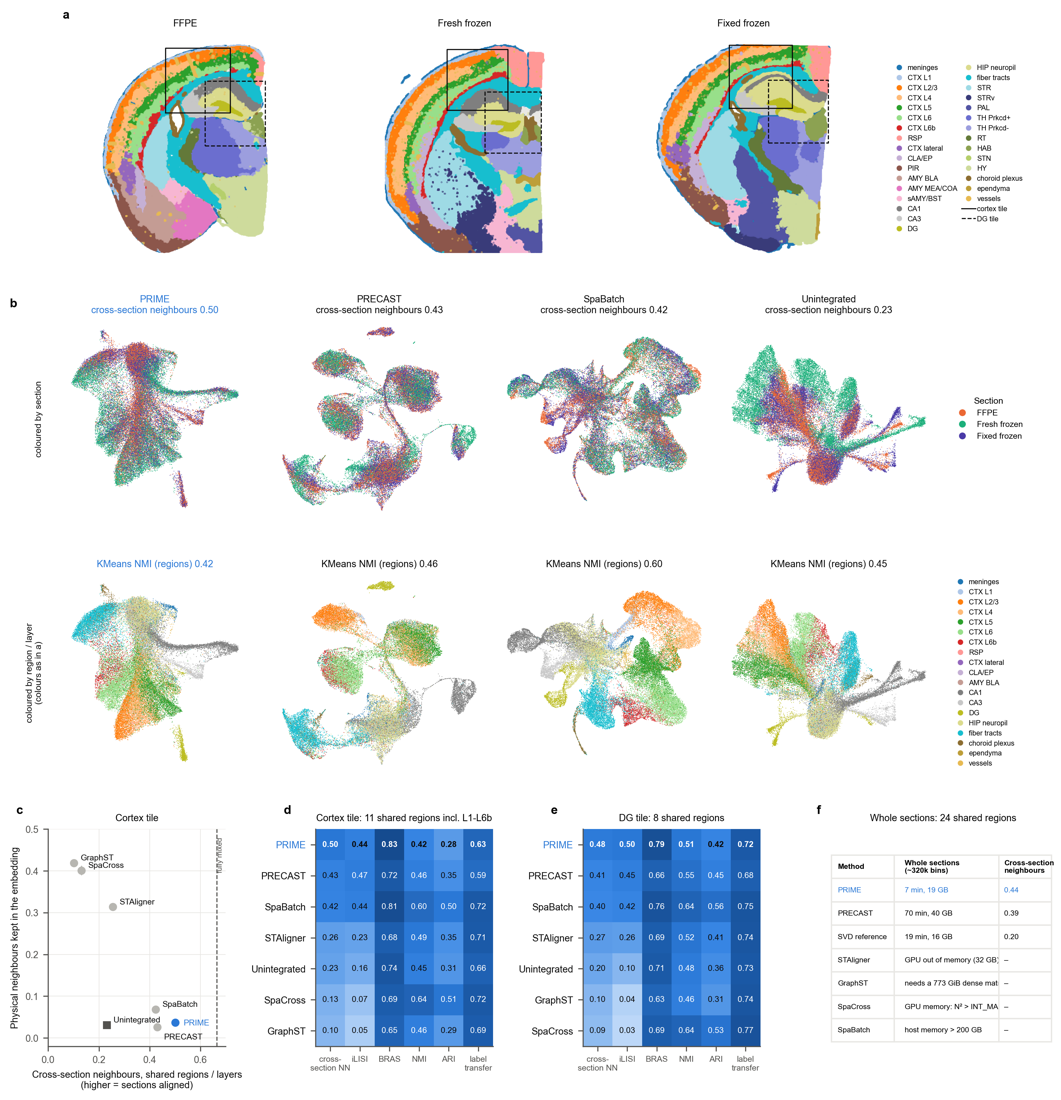

In [4]:
draw(fig_visiumhd_brain_integration, "visiumhd_brain_integration")

## Region and layer labels

The labels of `pipeline/visiumhd/annotate_regions.py` on the three sections (standard view), with both tile sets.

In [5]:
def fig_visiumhd_brain_annotation_map():
    """Region / layer labels of the three brain sections (standard view) with both tile sets."""
    annot = OUT / "visiumhd/brain/annot"
    if not (annot / "labels_region.tsv").exists():
        return
    from visiumhd.annotate_regions import LABEL_ORDER, view
    lab = pd.read_csv(annot / "labels_region.tsv", sep="\t", index_col=0)
    dom = pd.read_csv(annot / "domains.tsv", sep="\t", index_col=0, usecols=["key", "sample", "x_um", "y_um", "in_tile"])
    ctx = set(C.sc.read_h5ad(CFG["datasets"]["brain_cortex_tiles"]["path"], backed="r").obs_names)
    labs = [l for l in LABEL_ORDER if l in set(lab["label_region"])]
    pal = dict(zip(labs, (plt.get_cmap("tab20").colors + plt.get_cmap("tab20b").colors)[:len(labs)]))
    fig, axs = plt.subplots(1, 3, figsize=(13, 4.9))
    for ax, s_ in zip(axs, ["FFPE", "FreshFrozen", "FixedFrozen"]):
        d = dom[dom["sample"] == s_]
        x, y = view(d[["x_um", "y_um"]].to_numpy(float), s_, CFG)
        l = lab.loc[d.index, "label_region"].astype(str).to_numpy()
        ax.scatter(x[l == "nan"], y[l == "nan"], s=0.08, color=GRID, rasterized=True)
        for k in labs:
            ax.scatter(x[l == k], y[l == k], s=0.08, color=pal[k], rasterized=True)
        for mask, ls in ((d["in_tile"].to_numpy(bool), "--"), (d.index.isin(list(ctx)), "-")):
            tx, ty = x[mask], y[mask]
            ax.plot([tx.min(), tx.max(), tx.max(), tx.min(), tx.min()], [ty.min(), ty.min(), ty.max(), ty.max(), ty.min()],
                    color=INK, ls=ls, lw=0.8)
        ax.set_aspect("equal"); ax.axis("off")
        ax.set_title({"FFPE": "FFPE", "FreshFrozen": "Fresh frozen", "FixedFrozen": "Fixed frozen (mirrored)"}[s_] +
                     f"  ({len(d):,} bins)", fontsize=7)
    hd = [plt.Line2D([], [], ls="", marker="o", ms=3.5, color=pal[k], label=k) for k in labs]
    hd += [plt.Line2D([], [], color=INK, ls="-", lw=0.8, label="cortex tile"),
           plt.Line2D([], [], color=INK, ls="--", lw=0.8, label="DG tile"),
           plt.Line2D([], [], ls="", marker="o", ms=3.5, color=GRID, label="unlabelled")]
    fig.legend(handles=hd, loc="upper center", bbox_to_anchor=(0.5, 0.04), ncol=12, fontsize=6, handletextpad=0.2,
               columnspacing=0.8)
    save(fig, "visiumhd_brain_annotation_map")

wrote figures/visiumhd/visiumhd_brain_annotation_map


visiumhd_brain_annotation_map.png


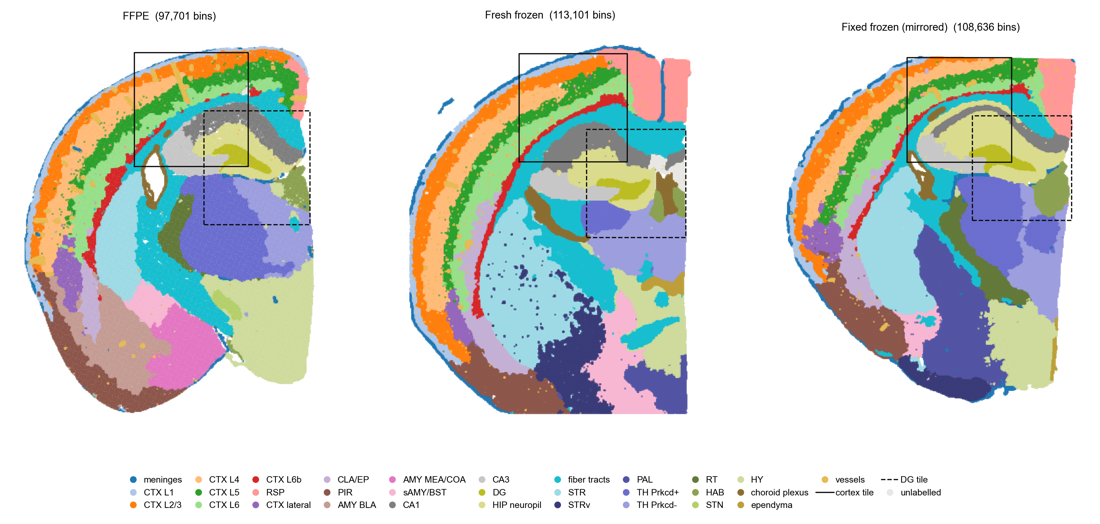

In [6]:
draw(fig_visiumhd_brain_annotation_map, "visiumhd_brain_annotation_map")

## Marker genes of the labels

Mean expression and detection rate of the marker panel for every label × section.

In [7]:
def fig_visiumhd_brain_annotation_markers():
    """Marker mean (colour, scaled to the gene maximum within the section) and detection rate (size) for every
    label x section (table written by annotate_regions.py labelmap)."""
    f = OUT / "visiumhd/brain/annot/labels_region_markers.tsv"
    if not f.exists():
        return
    dot = pd.read_csv(f, sep="\t")
    genes = [c.split(":", 1)[1] for c in dot.columns if c.startswith("mean:")]
    mean = dot[[f"mean:{g}" for g in genes]].to_numpy()
    frac = dot[[f"frac:{g}" for g in genes]].to_numpy()
    z = np.vstack([mean[i] / np.maximum(mean[(dot["sample"] == s_).to_numpy()].max(0), 1e-9)
                   for i, s_ in enumerate(dot["sample"])])
    short = {"FFPE": "FFPE", "FreshFrozen": "Fresh", "FixedFrozen": "Fixed"}
    ylab = [f"{r.label} | {short.get(r.sample, r.sample)}" for r in dot.itertuples()]
    fig, ax = plt.subplots(figsize=(0.2 * len(genes) + 1.6, 0.105 * len(dot) + 0.9))
    yy, xx = np.meshgrid(np.arange(len(dot)), np.arange(len(genes)), indexing="ij")
    sc_ = ax.scatter(xx.ravel(), yy.ravel(), s=frac.ravel() * 14, c=z.ravel(), cmap=SEQ, vmin=0, vmax=1,
                     edgecolors="none")
    ax.set_xticks(range(len(genes)), genes, rotation=90, fontsize=6, style="italic")
    ax.set_yticks(range(len(dot)), ylab, fontsize=5)
    ax.invert_yaxis()
    ax.set_xlim(-0.6, len(genes) - 0.4)
    ax.set_ylim(len(dot) - 0.4, -0.6)
    ax.grid(False)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(True)
    cb = fig.colorbar(sc_, ax=ax, fraction=0.04, pad=0.02, shrink=0.25, anchor=(0, 1))
    cb.set_label("mean (scaled to gene max\nwithin section)", fontsize=6)
    cb.ax.tick_params(labelsize=5.5)
    hs = [plt.Line2D([], [], ls="", marker="o", ms=np.sqrt(v * 14), color=INK2, label=f"{v:.0%}") for v in (0.25, 0.5, 1.0)]
    ax.legend(handles=hs, title="detected in", loc="upper left", bbox_to_anchor=(1.01, 0.62), fontsize=5.5,
              title_fontsize=6)
    save(fig, "visiumhd_brain_annotation_markers")

wrote figures/visiumhd/visiumhd_brain_annotation_markers


visiumhd_brain_annotation_markers.png


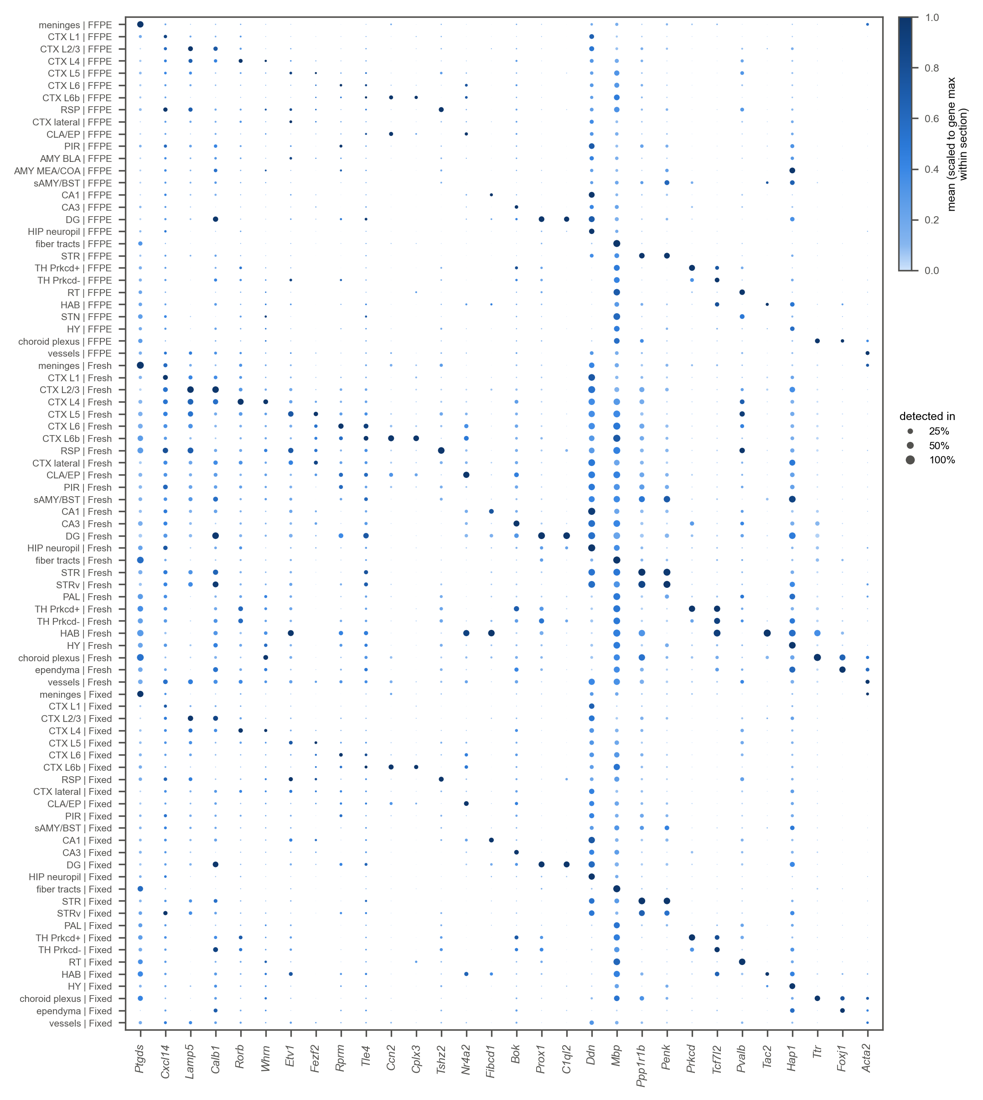

In [8]:
draw(fig_visiumhd_brain_annotation_markers, "visiumhd_brain_annotation_markers")